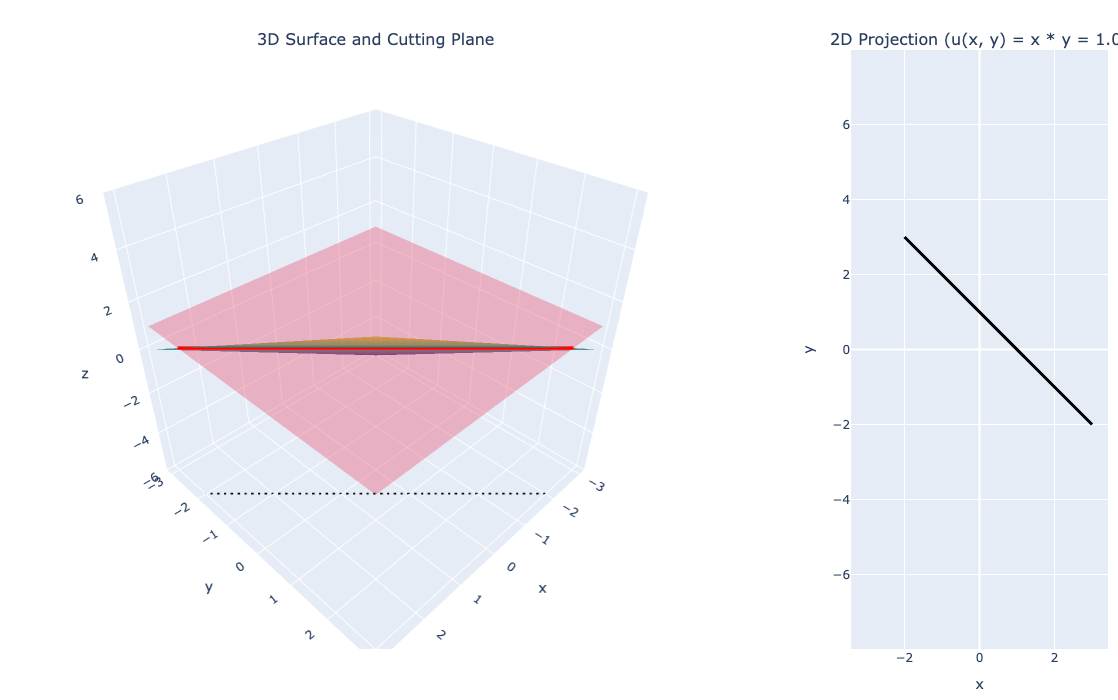

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# USER CONTROLS
# ==========================================
# Choose function: 1, 2, 3, or 4
FUNCTION_CHOICE = 4

# Height of horizontal cutting plane z = c
c = 1.0

x_range = (-3.0, 3.0)
y_range = (-3.0, 3.0)
grid_density = 100
# ==========================================

# Candidate multivariable potential functions u(x, y)
def f_1(x, y):
    return x**2 + y**2

def f_2(x, y):
    return x**2 - y**2

def f_3(x, y):
    return y - x**2

def f_4(x, y):
    return x + y

candidate_functions = {
    1: (f_1, "u(x, y) = x^2 + y^2"),
    2: (f_2, "u(x, y) = x^2 - y^2"),
    3: (f_3, "u(x, y) = y - x^2"),
    4: (f_4, "u(x, y) = x * y")
}

f, func_label = candidate_functions[FUNCTION_CHOICE]

# Generate spatial grid
x = np.linspace(x_range[0], x_range[1], grid_density)
y = np.linspace(y_range[0], y_range[1], grid_density)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

z_min, z_max = float(np.min(Z)), float(np.max(Z))

# Extract exact coordinate paths for u(x, y) = c
fig_temp = plt.figure()
cs = plt.contour(X, Y, Z, levels=[c])
plt.close(fig_temp)

# Create 1x2 layout: 3D plot allocated 74% width, 2D plot allocated 26% width
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.74, 0.26],
    specs=[[{'type': 'scene'}, {'type': 'xy'}]],
    subplot_titles=(
        '3D Surface and Cutting Plane',
        f'2D Projection ({func_label} = {c})'
    )
)

# 1. 3D Surface u(x, y)
fig.add_trace(
    go.Surface(
        x=X, y=Y, z=Z,
        colorscale='Viridis',
        opacity=0.75,
        showscale=False,
        showlegend=False
    ),
    row=1, col=1
)

# 2. Horizontal Cutting Plane z = c
plane_Z = np.full_like(Z, c)
fig.add_trace(
    go.Surface(
        x=X, y=Y, z=plane_Z,
        colorscale=[[0, 'crimson'], [1, 'crimson']],
        showscale=False,
        opacity=0.30,
        showlegend=False
    ),
    row=1, col=1
)

# 3. Contour curves in 3D and 2D Projection
for path in cs.get_paths():
    vertices = path.vertices
    x_c = vertices[:, 0]
    y_c = vertices[:, 1]
    z_c = np.full_like(x_c, c)
    z_proj = np.full_like(x_c, z_min)

    # Red contour curve on 3D surface at z = c
    fig.add_trace(
        go.Scatter3d(
            x=x_c, y=y_c, z=z_c,
            mode='lines',
            line=dict(color='red', width=7),
            showlegend=False
        ),
        row=1, col=1
    )

    # Black dashed projection on 3D floor at z = z_min
    fig.add_trace(
        go.Scatter3d(
            x=x_c, y=y_c, z=z_proj,
            mode='lines',
            line=dict(color='black', width=5, dash='dash'),
            showlegend=False
        ),
        row=1, col=1
    )

    # Black projection on side 2D xy-plane
    fig.add_trace(
        go.Scatter(
            x=x_c, y=y_c,
            mode='lines',
            line=dict(color='black', width=3),
            showlegend=False
        ),
        row=1, col=2
    )

# Configure 2D subplot axes
fig.update_xaxes(title_text='x', range=x_range, row=1, col=2, showgrid=True)
fig.update_yaxes(title_text='y', range=y_range, scaleanchor='x', scaleratio=1, row=1, col=2, showgrid=True)

# Configure 3D scene and overall figure sizing
fig.update_layout(
    height=700,
    showlegend=False,
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        zaxis=dict(range=[z_min, z_max]),
        aspectmode='cube'
    ),
    margin=dict(l=10, r=10, b=10, t=50),
    autosize=True
)

fig.show()